1. What is the average, median, and mode of PurchaseAmount?


Average Purchase Amount: 1003.9506701030928
Median Purchase Amount: 998.0799999999999
Mode Purchase Amount:
0    0.0
Name: PurchaseAmount, dtype: float64
Q1: 673.6424999999999
Q3: 1327.0775
IQR: 653.4350000000002
Lower Bound: -306.51000000000033
Upper Bound: 2307.2300000000005
Number of Outliers: 15
      CustomerID  Gender Region  PurchaseAmount ProductCategory Churn  \
195         1196    Male   West         2318.33         Fashion   Yes   
265         1266  Female   East         2496.41     Electronics   Yes   
348         1349    Male  South         2688.69     Electronics   Yes   
411         1412  Female  South         2349.16         Fashion   Yes   
826         1827    Male   East         2578.89     Electronics   Yes   
1358        2359    Male   West         2384.19     Electronics   Yes   
2285        3286    Male   East         2457.05         Grocery    No   
2557        3558    Male   East         2316.19         Fashion   Yes   
2681        3682  Female   East         24

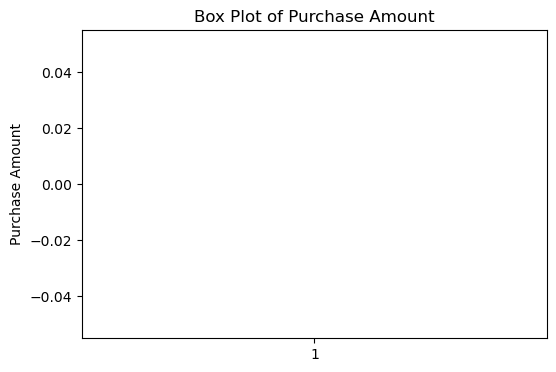

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("customer_data.csv") 

average_purchase = df['PurchaseAmount'].mean()
median_purchase = df['PurchaseAmount'].median()
mode_purchase = df['PurchaseAmount'].mode()

print("Average Purchase Amount:", average_purchase)
print("Median Purchase Amount:", median_purchase)
print("Mode Purchase Amount:")
print(mode_purchase)

2. Are there any outliers in the PurchaseAmount data?

Q1: 673.6424999999999
Q3: 1327.0775
IQR: 653.4350000000002
Lower Bound: -306.51000000000033
Upper Bound: 2307.2300000000005
Number of Outliers: 15
      CustomerID  Gender Region  PurchaseAmount ProductCategory Churn  \
195         1196    Male   West         2318.33         Fashion   Yes   
265         1266  Female   East         2496.41     Electronics   Yes   
348         1349    Male  South         2688.69     Electronics   Yes   
411         1412  Female  South         2349.16         Fashion   Yes   
826         1827    Male   East         2578.89     Electronics   Yes   
1358        2359    Male   West         2384.19     Electronics   Yes   
2285        3286    Male   East         2457.05         Grocery    No   
2557        3558    Male   East         2316.19         Fashion   Yes   
2681        3682  Female   East         2400.69         Fashion   Yes   
3326        4327  Female  North         2357.41         Grocery    No   
3438        4439  Female   East         2688.88   

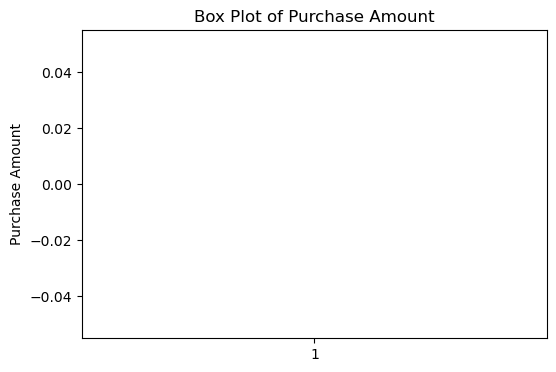

In [3]:
Q1 = df['PurchaseAmount'].quantile(0.25)
Q3 = df['PurchaseAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['PurchaseAmount'] < lower_bound) |(df['PurchaseAmount'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))
print(outliers)

plt.figure(figsize=(6,4))
plt.boxplot(df['PurchaseAmount'])
plt.title("Box Plot of Purchase Amount")
plt.ylabel("Purchase Amount")
plt.show()

3. Is there any skewness or kurtosis in the PurchaseAmount distribution?


Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705


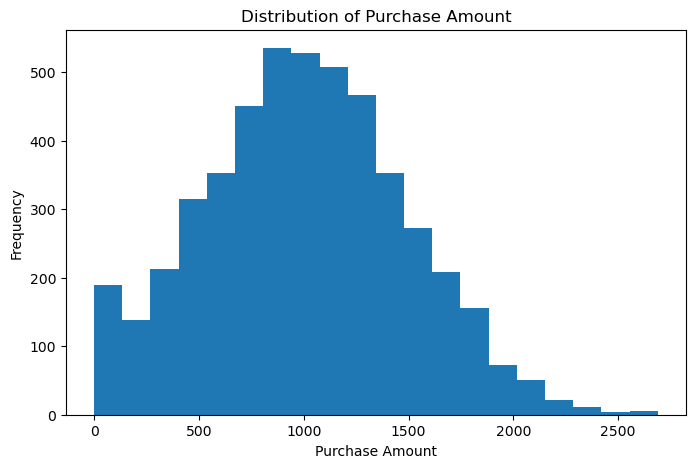

In [4]:
skewness = df['PurchaseAmount'].skew()
kurtosis = df['PurchaseAmount'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)
plt.figure(figsize=(8,5))
plt.hist(df['PurchaseAmount'], bins=20)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

4. Is there a significant difference in spending between male and female
customers?

T-statistic: nan
P-value: nan


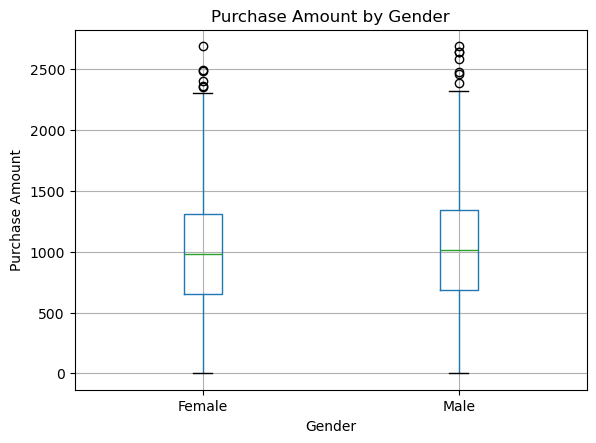

In [8]:
from scipy.stats import ttest_ind

male_spending = df[df['Gender'] == 'Male']['PurchaseAmount']
female_spending = df[df['Gender'] == 'Female']['PurchaseAmount']

t_stat, p_value = ttest_ind(male_spending, female_spending)

print("T-statistic:", t_stat)
print("P-value:", p_value)
df.boxplot(column='PurchaseAmount', by='Gender')
plt.title('Purchase Amount by Gender')
plt.suptitle('')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')
plt.show()

5. Is there a relationship between ProductCategory and customer churn?


Contingency Table:
Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604

Chi-Square Statistic: 0.3960436652673918
P-value: 0.8203519424988512
Degrees of Freedom: 2


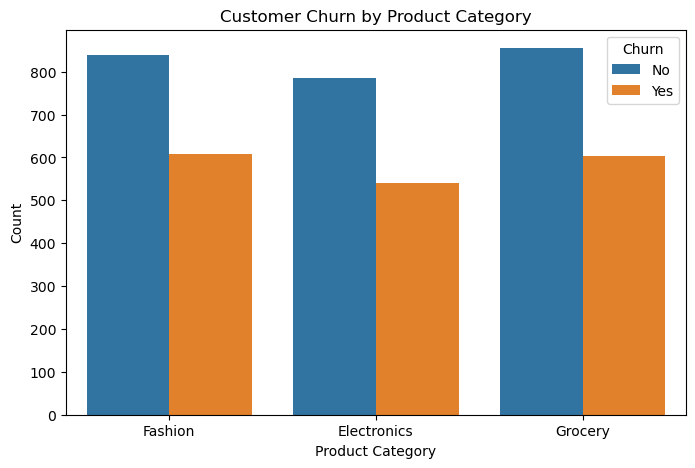

In [10]:
from scipy.stats import chi2_contingency
import seaborn as sns

contingency_table = pd.crosstab(df['ProductCategory'], df['Churn'])

print("Contingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='ProductCategory', hue='Churn')
plt.title('Customer Churn by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.show()


6. Does PurchaseAmount vary significantly across different regions?


F-statistic: nan
P-value: nan
Average Purchase Amount by Region:
Region
East     1009.946017
North    1013.017952
South     997.603877
West      995.247327
Name: PurchaseAmount, dtype: float64


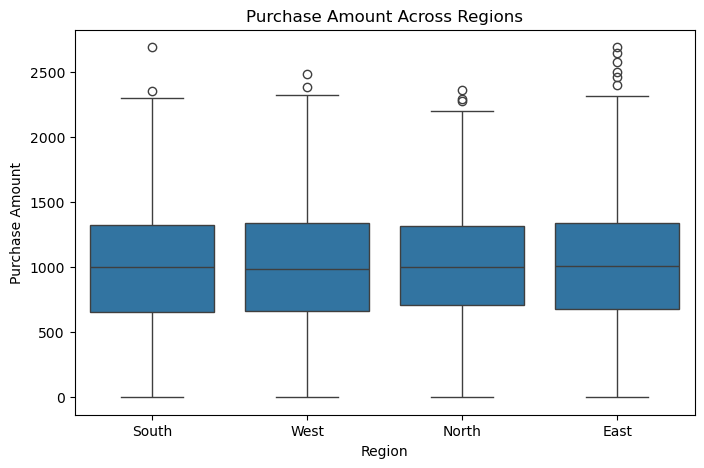

In [11]:
from scipy.stats import f_oneway

df = pd.read_csv("customer_data.csv")

regions = df['Region'].unique()

region_data = [
    df[df['Region'] == region]['PurchaseAmount']
    for region in regions
]

f_statistic, p_value = f_oneway(*region_data)

print("F-statistic:", f_statistic)
print("P-value:", p_value)

region_means = df.groupby('Region')['PurchaseAmount'].mean()

print("Average Purchase Amount by Region:")
print(region_means)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Region', y='PurchaseAmount')
plt.title('Purchase Amount Across Regions')
plt.xlabel('Region')
plt.ylabel('Purchase Amount')
plt.show()

7. Which email campaign (A or B) performed better in terms of average
PurchaseAmount?

Average Purchase Amount by Campaign:
CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64
T-statistic: nan
P-value: nan


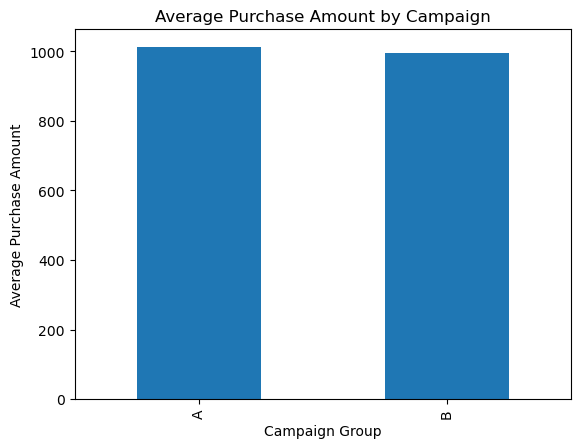

In [12]:
from scipy.stats import ttest_ind
campaign_avg = df.groupby('CampaignGroup')['PurchaseAmount'].mean()

print("Average Purchase Amount by Campaign:")
print(campaign_avg)

campaign_A = df[df['CampaignGroup'] == 'A']['PurchaseAmount']
campaign_B = df[df['CampaignGroup'] == 'B']['PurchaseAmount']

t_stat, p_value = ttest_ind(campaign_A, campaign_B)

print("T-statistic:", t_stat)
print("P-value:", p_value)
campaign_avg.plot(kind='bar')
plt.title('Average Purchase Amount by Campaign')
plt.xlabel('Campaign Group')
plt.ylabel('Average Purchase Amount')
plt.show()

8. Can we assume PurchaseAmount follows a normal distribution?

Test Statistic: nan
P-value: nan


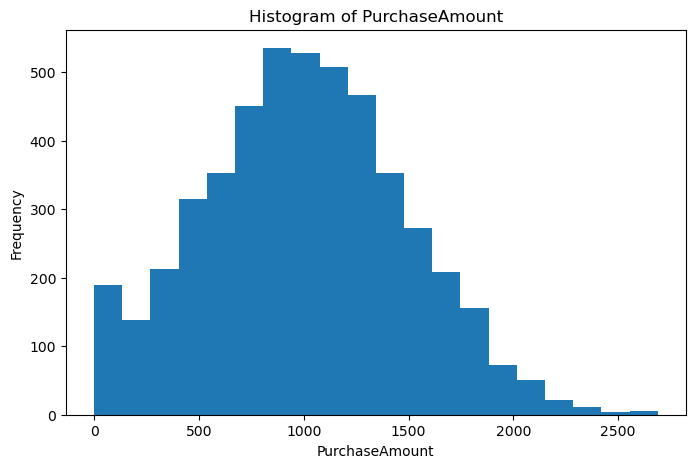

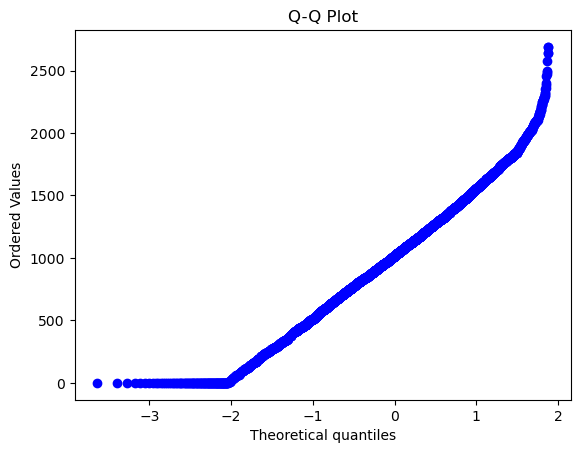

In [13]:
from scipy.stats import shapiro
import scipy.stats as stats

stat, p_value = shapiro(df['PurchaseAmount'])

print("Test Statistic:", stat)
print("P-value:", p_value)
plt.figure(figsize=(8,5))
plt.hist(df['PurchaseAmount'], bins=20)
plt.title('Histogram of PurchaseAmount')
plt.xlabel('PurchaseAmount')
plt.ylabel('Frequency')
plt.show()

stats.probplot(df['PurchaseAmount'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

9. What insights can we gain by applying the Central Limit Theorem?

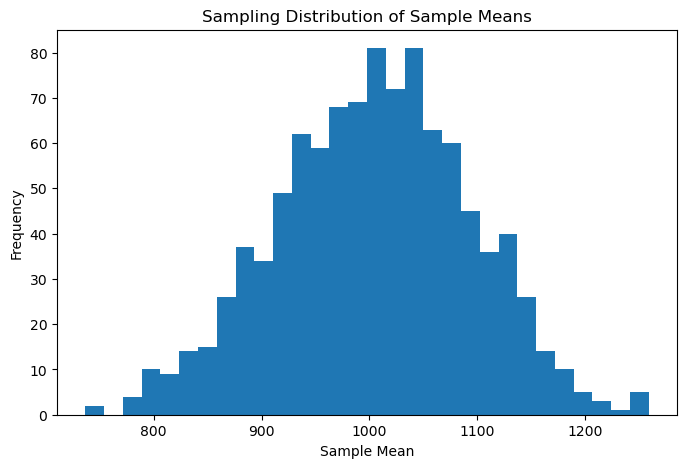

In [14]:
purchase_amounts = df['PurchaseAmount']
sample_means = []

for _ in range(1000):
    sample = purchase_amounts.sample(n=30, replace=True)
    sample_means.append(sample.mean())
plt.figure(figsize=(8,5))
plt.hist(sample_means, bins=30)
plt.title("Sampling Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

10.What is the 95% confidence interval for the average PurchaseAmount?

In [15]:
import numpy as np
import scipy.stats as stats

data = df['PurchaseAmount']

mean = np.mean(data)
std = np.std(data, ddof=1)
n = len(data)

confidence = 0.95
margin_error = stats.t.ppf((1 + confidence) / 2, df=n-1) * (std / np.sqrt(n))

lower_bound = mean - margin_error
upper_bound = mean + margin_error

print("Mean Purchase Amount:", mean)
print("95% Confidence Interval:")
print(f"({lower_bound:.2f}, {upper_bound:.2f})")

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(data)-1,
    loc=np.mean(data),
    scale=stats.sem(data)
)

print(confidence_interval)

Mean Purchase Amount: 1003.9506701030928
95% Confidence Interval:
(990.58, 1017.32)
(np.float64(nan), np.float64(nan))
